# Algoritmo genético (Módulo de diseño)

### 0.-Preámbulo

##### Importación de librerías

In [1]:
import random
import math
import numpy as np
from operator import attrgetter
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.image as mpimg
import random
import hashlib

##### Componentes principales del código (3): 
- 1.-Parámetros de entrada (Variables fijas)
- 2.-Generar el cromsoma
- 3.-ModeloTEM (Cálculo de ϵh , ϵh, cálculo de Nf y Ndp, y cálculo del Daño)
- 4.-Algoritmo genético (Optimización)
                  

### 1.-Parámetros de entrada (1 de 3)

##### 1.1.- Tipo de estructura a diseñar

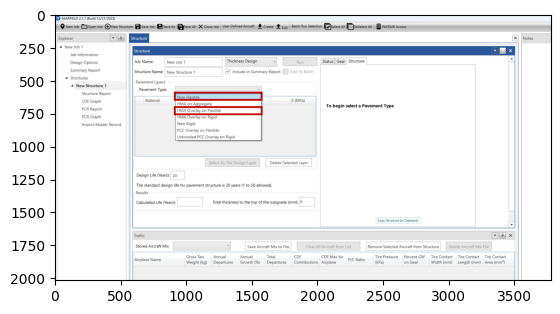

In [142]:
#Tipo de estructura a diseñar se debe seleccionar en FAARFIELD para comenzar el análisis 
Tipoestructura="new flexible"                 #"new flexible" o "hma overlay on flexible". A la función yo le debo poder pasar el tipo de estructura a diseñar, para que lo seleccione en FAARFIELD.
plt.imshow(mpimg.imread("Tipoestructura.png"))

##### 1.2.-Flota de diseño

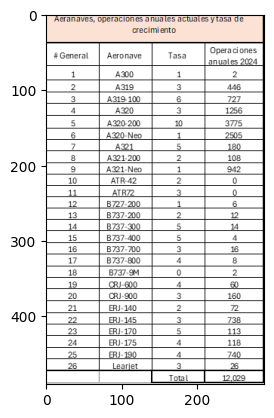

In [143]:
#Flota de diseño (dato)                       #Es una tabla de datos que debo pasarle al programa, contiene; lista de aeronaves, con su tasa de crecimiento y número de operaciones anuales
#Cuando yo pase la flota de diseño y se cargue en el porgrama, necesito que la función me extraiga la aeronave que pesa más de esa flota y su peso, esto en necesario para definir el tipo de base 
    #que se va a utilizar en la estructura BTA o BG
plt.imshow(mpimg.imread("flota.png"))

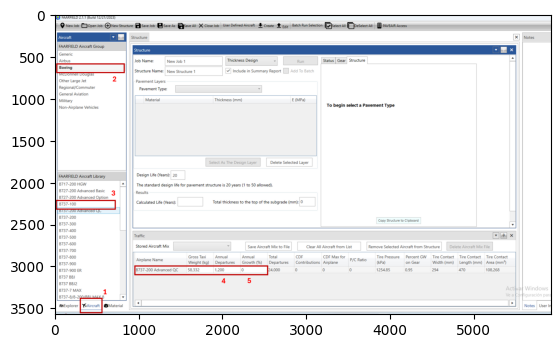

In [144]:
#Cargar la flota en Faarfield
plt.imshow(mpimg.imread("FlotaFar.png"))

##### 1.3.-Tipo de base a utilizar

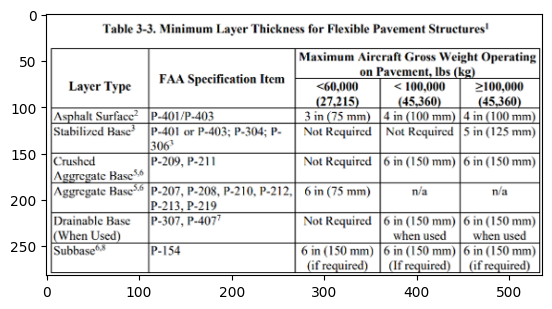

In [145]:
#Tipo de base a utilizar BTA o BG. 
    #Si MTOW_MAX (peso máximo de aeronave) es menor a 45,360 kg, se usa BG, si es mayor se usa BTA
MTOW_MAX=20000 #De momento lo estoy ingresando como dato, pero debe extraerse de Faafield, después de cargar la flota.
plt.imshow(mpimg.imread("Espesores.png"))

##### 1.4.- Módulo del terreno natural (subrade) o CBR

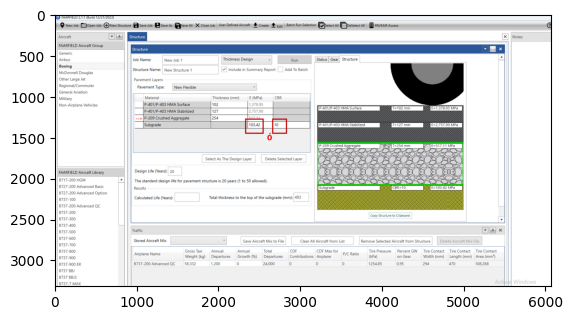

In [146]:
#Ingresar módulo de subgrade (terreno natural) (E(MPa)) o CBR
ETN=120                             #Módulo del terreno natural (dato), de este valor depende el número de capas que tendrá la estructura que puede ser 3, 4 o 5. A la función debo poder pasarle módulo o CBR
plt.imshow(mpimg.imread("TN.png"))

##### 1.5.-Número de capas de al estructura = número de genes en mi cormosoma

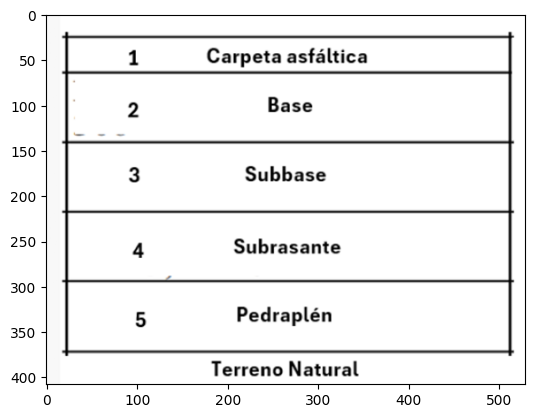

In [147]:
#Número de capas en la estructura en función de la categoria (Módulo de TN)
plt.imshow(mpimg.imread("Estructura.png")) #Ejemplo de estructura de pavimento con 5 capas
#Una vez definido el número de capas se genera el cormosoma con tantos genes como capas tenga la estructura 

| Categoría de terreno antural | **A** | **B** | **C** | **D** | **E** | **F** |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Módulo Elástico ($E_{TN}$) [MPa]** | $>150$ | $\ge 100 \text{ y } < 150$ | $\ge 60 \text{ y } < 100$ | $< 60$ | $< 50$ | $< 30$ |
| **Número de Capas por categoría** | 3 | 3 | 4 | 4 | 5 | 5 |
| **Genes Activos (Capas (1 al 5) y módulo de HMA (6))** | $e_1, e_2, e_3, e_6$ | $e_1, e_2, e_3, e_6$ | $e_1, e_2, e_3, e_4, e_6$ | $e_1, e_2, e_3, e_4, e_6$ | $e_1, e_2, e_3, e_4, e_5, e_6$ | $e_1, e_2, e_3, e_4, e_5, e_6$ |


![Cromosoma](Cromosoma.png)

Mi cromosoma se puede componer de hasta 6 genes

- e1    (eHMA): Espesor de la Carpeta Asfáltica (Mezcla Asfáltica Caliente).

- e2    (eBTAoBG): Espesor de la Base Tratada con Asfalto (BTA) o Espesor de la Base granular (BG)
- e3    (eSB): Espesor de la Subbase (SB).

- e4    (eSR): Espesor de la Subrasante (SR).

- e5    (eP) : Espesor del Pedráplen (P). 

- e6    (EHMA): Módulo Elástico de la Carpeta Asfáltica (HMA).


##### 1.6.- Periodo de diseño

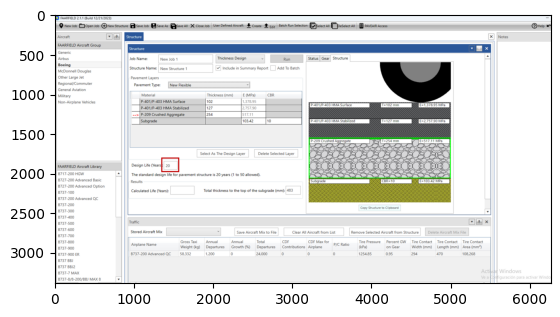

In [148]:
Periododiseño=20 #Este dado debo poder pasarselo a Faarfield
plt.imshow(mpimg.imread("Pdiseño.png"))


##### 1.7.-ACR MAXIMO

In [149]:
ACR_max = 450                    #Este valor lo estoy pasando como dato de momento, FAARFIELD en módulo de "PCR" calcula los ACR para todas las aeronaves de la flota que le ingreso
                                 #Yo requiero extraer este valo con la función, xq de este valor depende el rango del PCR

##### 1.8.- Datos para el algoritmo genético

In [150]:
TAM_POBLACION = 50
NUM_GENERACIONES = 30
PROB_CRUZA = 0.8
PROB_MUTACION = 0.1
k=3 #Tamaño del torneo 

### 2.-Generar cromosoma

##### 2.1.-Número de genes acitvos en función de la categoria de Terreno natural o subrasante

In [151]:
# Mapeo de índices de genes a tipo de capa:
# 1: e_HMA, 2: e_Base, 3: e_Subbase, 4: e_Subrasante, 5: e_Pedraplen, 6: E_HMA

def obtener_estructura(ETN):
    """Determina la categoría del terreno natural (ETN) y la lista de índices de genes activos."""
    
    # 1. Definición de Categorías
    if ETN > 150:
        categoria = 'A'
        # Capas variables: Carpeta (1), Base (2), Subbase (3)
        indices_espesor_activos = [1, 2, 3] 
    elif 100 <= ETN <= 150:
        categoria = 'B'
        # Capas variables: Carpeta (1), Base (2), Subbase (3)
        indices_espesor_activos = [1, 2, 3]
    elif 60 <= ETN < 100:
        categoria = 'C'
        # Capas variables: Carpeta (1), Base (2), Subbase (3), Subrasante (4)
        indices_espesor_activos = [1, 2, 3, 4]
    elif 50 <= ETN < 60:
        categoria = 'D'
        # Capas variables: Carpeta (1), Base (2), Subbase (3), Subrasante (4)
        indices_espesor_activos = [1, 2, 3, 4]
    elif 30 <= ETN < 50:
        categoria = 'E'
        # Capas variables: Carpeta (1), Base (2), Subbase (3), Subrasante (4), Pedraplén (5)
        indices_espesor_activos = [1, 2, 3, 4, 5]
    else: # ETN < 30
        categoria = 'F'
        # Capas variables: Carpeta (1), Base (2), Subbase (3), Subrasante (4), Pedraplén (5)
        indices_espesor_activos = [1, 2, 3, 4, 5]
        
    # 2. Agregar el Módulo EHMA (Gen 6), que siempre es variable.
    indices_espesor_activos.append(6) 
    
    return categoria, indices_espesor_activos

# --- Función Auxiliar para la Decodificación Final ---
def get_nombre_capa(idx):
    """Mapea el índice del gen a un nombre legible."""
    mapping = {
        1: 'Carpeta Asfáltica (HMA)', 
        2: 'Base (BTA/BG)', 
        3: 'Subbase (SB)', 
        4: 'Subrasante (SR)', 
        5: 'Pedraplén (PD)', 
        6: 'Módulo EHMA (EHMA)'
    }
    return mapping.get(idx, 'ERROR')

##### 2.2.-Parámetros fijos, rangos y tamaños de pasos de los genes

In [152]:
class ParametrosPavimento:
    def __init__(self, ETN, MTOW_MAX): # MTOW_MAX en kg (Asumimos tráfico pesado > 45,360 kg)
        
        # --- DEFINICIÓN DE ESTRUCTURA Y VARIABLES ---
        self.ETN = ETN
        self.Categoria, self.IndicesActivos = obtener_estructura(ETN)
        self.LONGITUD_CROMOSOMA = len(self.IndicesActivos)
        
        # --- CONDICIÓN DE CARGA (Para seleccionar BTA o BG) ---
        if MTOW_MAX > 45360:
            self.TIPO_BASE = 'BTA'  # Base Tratada con Asfalto
            self.HMA_RANGO = {'min': 100, 'max': 150, 'paso': 10} # 100 a 150 mm
            self.B_RANGO = {'min': 125, 'max': 275, 'paso': 50} # 125 a 250 mm
            self.E_BASE_VALOR = 2757.9 # Módulo para Base Tratada con Asfalto (MPa) #Esta capa esta predefinida en el programa
        else:
            self.TIPO_BASE = 'BG'   # Base Granular
            self.HMA_RANGO = {'min': 75, 'max': 125, 'paso': 10}
            self.B_RANGO = {'min': 150, 'max': 300, 'paso': 50} # 125 a 250 mm
            self.E_BASE_VALOR = 220 # Módulo para Base Granular (MPa)
            
        # --- MÓDULOS DE ELASTICIDAD FIJOS (Fenotipo) ---
        # Estos valores se usarán para construir el vector E para el TEM
        self.E = {
            'Base': self.E_BASE_VALOR, 
            'Subbase': 180, # Módulo para Subbase (MPa)
            'Subrasante': 75, # Módulo para Subrasante (MPa)
            'Pedraplen': 90, # Módulo para Pedraplén (MPa)
            'Terreno_Natural': self.ETN #Módulo del terreno natural (MPa)
        }
        
        # --- RANGOS Y CÓDIGO DISCRETO DE LOS GENES POTENCIALES (ÍNDICES 1 a 6) ---
        # El índice del diccionario corresponde al número de gen (1 a 6)
        self.RANGOS_GEN = {
            1: self.HMA_RANGO,                       # e_1: Espesor de Carpeta Asfáltica (HMA) (el rango depende del peso de aeronaves)
            2: self.B_RANGO,                         # e_2: Espesor Base (BTA/BG) (el rango depende del tipo de base que depende del peso de aeronaves)
            3: {'min': 150, 'max': 350, 'paso': 50}, # e_3: Subbase (SB)
            4: {'min': 300, 'max': 500, 'paso': 50}, # e_4: Subrasante (SR)
            5: {'min': 300, 'max': 500, 'paso': 50}, # e_5: Pedraplén (PD)
            6: {'min': 28000, 'max': 35000, 'paso': 1000} # E_6: Módulo Carpeta Asfáltica
        }

    def get_num_indices(self, gen_idx):
        """Calcula el número de índices válidos para un gen dado (de 1 a 6)."""
        r = self.RANGOS_GEN[gen_idx]
        return int((r['max'] - r['min']) / r['paso']) + 1

    # Función crucial para la decodificación en el Fitness
    def get_capa_tipo(self, idx_activo):
        """Mapea el índice activo (1 a 6) al tipo de capa para obtener Módulos y Poisson."""
        if idx_activo == 1: return 'CarpetaAsfaltica'
        if idx_activo == 2: return 'Base'
        if idx_activo == 3: return 'Subbase'
        if idx_activo == 4: return 'Subrasante'
        if idx_activo == 5: return 'Pedraplen'
        if idx_activo == 6: return 'ModuloEHMA' 
        return 'Error'

##### 2.3.-Generar cromosoma incial y decodificarlo

In [153]:
def generar_cromosoma_inicial(params):
    """
    Crea un cromosoma aleatorio (vector de índices) de la longitud correcta,
    asegurando que cada índice esté dentro de su rango válido.
    """
    cromosoma = []
    
    # Iteramos sobre los índices de genes activos [1, 2, 3, 4, 5, 6] para ETN=29
    for idx_gen in params.IndicesActivos:
        # 1. Obtenemos el número máximo de índices (ej. 0 a 7)
        max_indice_valido = params.get_num_indices(idx_gen) - 1 
        
        # 2. Generamos un índice aleatorio dentro del rango [0, max_indice_valido]
        indice_discreto = random.randint(0, max_indice_valido)
        
        # 3. Añadimos el índice al cromosoma
        cromosoma.append(indice_discreto)
        
    return cromosoma

def decodificar_cromosoma(cromosoma, params):
    """Convierte el cromosoma de índices discretos a valores físicos y los retorna como diccionario y vector."""
    valores_fisicos_dict = {}
    vector_valores_reales = []
    
    for i, idx_gen in enumerate(params.IndicesActivos):
        indice_discreto = cromosoma[i]
        rango = params.RANGOS_GEN[idx_gen]
        
        valor = rango['min'] + (indice_discreto * rango['paso'])
        
        nombre_capa = get_nombre_capa(idx_gen)
        
        valores_fisicos_dict[nombre_capa] = valor
        
        # Formateo del valor con su unidad para el vector de impresión
        unidad = 'mm' if idx_gen < 6 else 'MPa'
        vector_valores_reales.append(f"{valor} {unidad}")

    return valores_fisicos_dict, vector_valores_reales

if __name__ == "__main__":
    
        
    # 1. Inicializar la configuración
    config = ParametrosPavimento(ETN, MTOW_MAX)
    
    print(f"--- Configuración Inicial (ETN = {ETN} MPa)" )
    print(f"Categoría de terreno natural: {config.Categoria}")
    print(f"Longitud del Cromosoma (Genes Activos): {config.LONGITUD_CROMOSOMA}")
    print(f"Tipo de Base: {config.TIPO_BASE}\n")
    
    # 2. Generar y decodificar el cromosoma inicial
    cromosoma_inicial = generar_cromosoma_inicial(config)
    diseno_fenotipo, vector_reales = decodificar_cromosoma(cromosoma_inicial, config)
    
    print("--- 🧬 Cromosoma Inicial (Genotipo) ---")
    print(f"Vector de Índices: {cromosoma_inicial}")
    
    print("\n--- 🛠️ Diseño Físico (Fenotipo) ---")
    
    # Imprime el vector de valores reales
    print(f"Vector de Valores Reales: {vector_reales}")
    
    # Imprime el detalle (para mejor legibilidad)
    print("\nDetalle de Mapeo:")
    indices_activos = config.IndicesActivos
    nombres_capas = [get_nombre_capa(i) for i in indices_activos]

    for nombre, valor_real in zip(nombres_capas, vector_reales):
        print(f"* {nombre}: {valor_real}")

--- Configuración Inicial (ETN = 120 MPa)
Categoría de terreno natural: B
Longitud del Cromosoma (Genes Activos): 4
Tipo de Base: BG

--- 🧬 Cromosoma Inicial (Genotipo) ---
Vector de Índices: [3, 3, 2, 6]

--- 🛠️ Diseño Físico (Fenotipo) ---
Vector de Valores Reales: ['105 mm', '300 mm', '250 mm', '34000 MPa']

Detalle de Mapeo:
* Carpeta Asfáltica (HMA): 105 mm
* Base (BTA/BG): 300 mm
* Subbase (SB): 250 mm
* Módulo EHMA (EHMA): 34000 MPa


### 3.-Cálculo de CDFsr, CDFhma, Vida y PCR

#Aqui es donde debería ir la función que están ayudando a desarrollar. Por ahora utilice una función que me de valores a azar (CDFsr, CDFhma, Vida y PCR) para cada cromosoma, pero estos valores deben ser calculados con FAARFIELD

In [154]:
#Función tipo mock (función temporal q imita el comportamiento de una función real). No pueden ser valores aleatorios, xq el algoritmo no funcionaría

def evaluar_cromosoma_mock(
    cromosoma, params,
    CDFsr_min=0.96, CDFsr_max=0.99,
    CDFhma_min=0.96, CDFhma_max=0.99,
    Vida_min=Periododiseño, Vida_max=1.1*Periododiseño,
    PCR_min=ACR_max, PCR_max=1.1*ACR_max
):
    import hashlib
    import random

    valores_fisicos, _ = decodificar_cromosoma(cromosoma, params)

    e_hma = valores_fisicos.get('Carpeta Asfáltica (HMA)', 0)
    e_base = valores_fisicos.get('Base (BTA/BG)', 0)
    e_subbase = valores_fisicos.get('Subbase (SB)', 0)
    e_subrasante = valores_fisicos.get('Subrasante (SR)', 0)
    e_pedraplen = valores_fisicos.get('Pedraplén (PD)', 0)
    E_hma = valores_fisicos.get('Módulo EHMA (EHMA)', 0)

    texto = f"{cromosoma}-{params.ETN}-{params.TIPO_BASE}"
    semilla = int(hashlib.sha256(texto.encode()).hexdigest(), 16) % (10**8)
    rng = random.Random(semilla)

    puntaje = (
        0.040 * e_hma +
        0.020 * e_base +
        0.015 * e_subbase +
        0.010 * e_subrasante +
        0.008 * e_pedraplen +
        0.0010 * E_hma +
        0.10 * params.ETN
    )

    # Función logística para llevar cualquier puntaje a [0,1]
    t = 1 / (1 + pow(2.718281828, -0.08 * (puntaje - 50)))

    ruido_cdfsr = rng.uniform(-0.002, 0.002)
    ruido_cdfhma = rng.uniform(-0.002, 0.002)
    ruido_vida = rng.uniform(-0.15, 0.15)
    ruido_pcr = rng.uniform(-0.8, 0.8)

    CDFsr = CDFsr_min + t * (CDFsr_max - CDFsr_min) + ruido_cdfsr
    CDFhma = CDFhma_min + t * (CDFhma_max - CDFhma_min) + ruido_cdfhma
    Vida = Vida_min + t * (Vida_max - Vida_min) + ruido_vida
    PCR = PCR_min + t * (PCR_max - PCR_min) + ruido_pcr

    CDFsr = max(CDFsr_min, min(CDFsr_max, CDFsr))
    CDFhma = max(CDFhma_min, min(CDFhma_max, CDFhma))
    Vida = max(Vida_min, min(Vida_max, Vida))
    PCR = max(PCR_min, min(PCR_max, PCR))

    return {
        'CDFsr': round(CDFsr, 4),
        'CDFhma': round(CDFhma, 4),
        'Vida': round(Vida, 2),
        'PCR': round(PCR, 2)
    }


### 4.-Algoritmo genético 

##### 4.1.- Función para normalizar

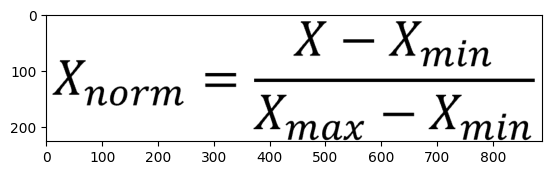

In [155]:
#Normalizar
def normalizar(valor, vmin, vmax):

    if vmax == vmin:
        return 0.0
    return abs(valor - vmin) / (vmax - vmin)
plt.imshow(mpimg.imread("normalizar.png"))

##### 4.2.- Normalización de valores objetivo

In [156]:
#CDF subrasante
CDFsro=0.98       #Valor objetivo
CDFsrmin=0.96     #Valor mínimo
CDFsrmax=0.99     #Valor máximo
CDFsrn=normalizar(CDFsro,CDFsrmin,CDFsrmax)

#CDF carpeta asfáltica (HMA)
CDFhmao=0.98
CDFhmamin=0.96
CDFhmamax=0.99
CDFhman=normalizar(CDFhmao,CDFhmamin,CDFhmamax)

#Vida estructural
Vidao=Periododiseño
Vidamin=Periododiseño
Vidamax=1.1*Periododiseño
Vidan=normalizar(Vidao,Vidamin,Vidamax)

#Resistencia d ela estructura 
PCRo=ACR_max
PCRmin = ACR_max
PCRmax = 1.1*ACR_max
PCRn=normalizar(PCRo,PCRmin,PCRmax) 

##### 4.3.-Función fitness

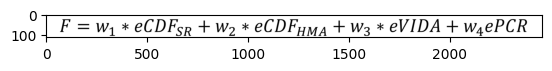

In [157]:
plt.imshow(mpimg.imread("F1.png"))

w1=0.3      #Pesos que suman 1 en total
w2=0.3
w3=0.15
w4=0.25

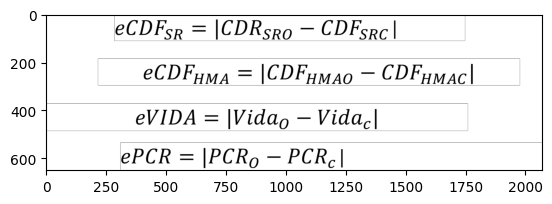

In [158]:
#Cálculo del error 
plt.imshow(mpimg.imread("F2.png"))

In [159]:
#Función para cálculo sel fitness
def calcular_fitness(eCDFsr, eCDFhma, eVida, ePCR, w1, w2, w3, w4):
    """
    Calcula el fitness como suma ponderada de los errores normalizados.
    """
    F = (w1 * eCDFsr + w2 * eCDFhma + w3 * eVida + w4 * ePCR)
    return F

In [160]:
#Generar resultados de un individuo (CDFsr, CDFhma, Vida, PCR)con la función mock (lo que debe generar farrfield) y calcular su fitness
def evaluar_individuo_mock(cromosoma, params, ACR_max):
    """
    Evalúa un cromosoma con resultados simulados y calcula fitness.
    """
    valores_fisicos, vector_reales = decodificar_cromosoma(cromosoma, params)
    resultado = evaluar_cromosoma_mock(cromosoma, params)
    return resultado


In [161]:
def evaluar_fitness_individuo(individuo,
                              CDFsrn, CDFhman, Vidan, PCRn,
                              CDFsrmin, CDFsrmax,
                              CDFhmamin, CDFhmamax,
                              Vidamin, Vidamax,
                              PCRmin, PCRmax,
                              w1, w2, w3, w4):

    # extraer valores del individuo
    CDFsrc = individuo["CDFsr"]
    CDFhmac = individuo["CDFhma"]
    Vidac = individuo["Vida"]
    PCRc = individuo["PCR"]

    # normalización de valores calculados
    CDFsrcn = normalizar(CDFsrc, CDFsrmin, CDFsrmax)
    CDFhmacn = normalizar(CDFhmac, CDFhmamin, CDFhmamax)
    Vidacn = normalizar(Vidac, Vidamin, Vidamax)
    PCRcn = normalizar(PCRc, PCRmin, PCRmax)

    # cálculo de errores
    eCDFsr = abs(CDFsrn - CDFsrcn)
    eCDFhma = abs(CDFhman - CDFhmacn)
    eVida = abs(Vidan - Vidacn)
    ePCR = abs(PCRn - PCRcn)

    # cálculo del fitness
    F = calcular_fitness(eCDFsr, eCDFhma, eVida, ePCR, w1, w2, w3, w4)

    # guardar fitness en el individuo
    individuo["fitness"] = F

    return F, eCDFsr, eCDFhma, eVida, ePCR

##### 4.4.- Implenetación del Algoritmo

###### 4.4.1.-Generar población

In [162]:
#Genera un cromosoma
#Decodificar el cromosoma
#Genera los CDFsr, CDFhma, Vida y PCR con la función mock (Debería hacerlo al función)
#Calcular el fitness
#Genera una población
def generar_poblacion(params, ACR_max, TAM_POBLACION,
                      CDFsrn, CDFhman, Vidan, PCRn,
                      CDFsrmin, CDFsrmax,
                      CDFhmamin, CDFhmamax,
                      Vidamin, Vidamax,
                      PCRmin, PCRmax,
                      w1, w2, w3, w4):
    """
    Genera una población de individuos con:
    - cromosoma
    - cromosoma decodificado
    - resultados del mock
    - fitness
    """

    poblacion = []

    for _ in range(TAM_POBLACION):
        # 1. Generar cromosoma
        cromosoma = generar_cromosoma_inicial(params)

        # 2. Evaluar individuo con la función mock
        individuo = evaluar_individuo_mock(cromosoma, params, ACR_max)

        # 3. Guardar cromosoma
        individuo["cromosoma"] = cromosoma

        # 4. Decodificar cromosoma
        valores_dict, vector_real = decodificar_cromosoma(cromosoma, params)
        individuo["cromosoma_decodificado"] = vector_real
        individuo["valores_fisicos"] = valores_dict

        # 5. Calcular fitness
        fitness, eCDFsr, eCDFhma, eVida, ePCR = evaluar_fitness_individuo(
            individuo,
            CDFsrn, CDFhman, Vidan, PCRn,
            CDFsrmin, CDFsrmax,
            CDFhmamin, CDFhmamax,
            Vidamin, Vidamax,
            PCRmin, PCRmax,
            w1, w2, w3, w4
        )

        # 6. Guardar fitness y errores
        individuo["fitness"] = fitness
        individuo["eCDFsr"] = eCDFsr
        individuo["eCDFhma"] = eCDFhma
        individuo["eVida"] = eVida
        individuo["ePCR"] = ePCR

        # 7. Agregar individuo a la población
        poblacion.append(individuo)

    return poblacion

In [163]:
params = ParametrosPavimento(ETN, MTOW_MAX)

In [164]:
poblacion = generar_poblacion(
    params=params,
    ACR_max=ACR_max,
    TAM_POBLACION=TAM_POBLACION,
    CDFsrn=CDFsrn,
    CDFhman=CDFhman,
    Vidan=Vidan,
    PCRn=PCRn,
    CDFsrmin=CDFsrmin,
    CDFsrmax=CDFsrmax,
    CDFhmamin=CDFhmamin,
    CDFhmamax=CDFhmamax,
    Vidamin=Vidamin,
    Vidamax=Vidamax,
    PCRmin=PCRmin,
    PCRmax=PCRmax,
    w1=w1,
    w2=w2,
    w3=w3,
    w4=w4
)

In [165]:
poblacion

[{'CDFsr': 0.9826,
  'CDFhma': 0.9802,
  'Vida': 21.47,
  'PCR': 482.17,
  'cromosoma': [3, 2, 3, 7],
  'cromosoma_decodificado': ['105 mm', '250 mm', '300 mm', '35000 MPa'],
  'valores_fisicos': {'Carpeta Asfáltica (HMA)': 105,
   'Base (BTA/BG)': 250,
   'Subbase (SB)': 300,
   'Módulo EHMA (EHMA)': 35000},
  'fitness': 0.3169722222222222,
  'eCDFsr': 0.08666666666666822,
  'eCDFhma': 0.0066666666666659324,
  'eVida': 0.7349999999999994,
  'ePCR': 0.7148888888888884},
 {'CDFsr': 0.9823,
  'CDFhma': 0.9788,
  'Vida': 21.46,
  'PCR': 480.19,
  'cromosoma': [3, 2, 4, 5],
  'cromosoma_decodificado': ['105 mm', '250 mm', '350 mm', '33000 MPa'],
  'valores_fisicos': {'Carpeta Asfáltica (HMA)': 105,
   'Base (BTA/BG)': 250,
   'Subbase (SB)': 350,
   'Módulo EHMA (EHMA)': 33000},
  'fitness': 0.3122222222222215,
  'eCDFsr': 0.07666666666666555,
  'eCDFhma': 0.03999999999999926,
  'eVida': 0.7300000000000004,
  'ePCR': 0.670888888888888},
 {'CDFsr': 0.9787,
  'CDFhma': 0.9784,
  'Vida': 21.4

In [166]:
def poblacion_a_tabla(poblacion):
    
    filas = []

    for i, ind in enumerate(poblacion):
        fila = {
            "Individuo": i + 1,
            "Cromosoma": ind["cromosoma"],
            "Cromosoma_decodificado": ind["cromosoma_decodificado"],
            "CDFsr": ind["CDFsr"],
            "CDFhma": ind["CDFhma"],
            "Vida": ind["Vida"],
            "PCR": ind["PCR"],
            "eCDFsr": ind["eCDFsr"],
            "eCDFhma": ind["eCDFhma"],
            "eVida": ind["eVida"],
            "ePCR": ind["ePCR"],
            "Fitness": ind["fitness"]
        }
        filas.append(fila)

    df = pd.DataFrame(filas)
    return df

In [167]:
tabla = poblacion_a_tabla(poblacion)

print(tabla)

    Individuo     Cromosoma               Cromosoma_decodificado   CDFsr  \
0           1  [3, 2, 3, 7]  [105 mm, 250 mm, 300 mm, 35000 MPa]  0.9826   
1           2  [3, 2, 4, 5]  [105 mm, 250 mm, 350 mm, 33000 MPa]  0.9823   
2           3  [2, 2, 2, 6]   [95 mm, 250 mm, 250 mm, 34000 MPa]  0.9787   
3           4  [5, 2, 2, 1]  [125 mm, 250 mm, 250 mm, 29000 MPa]  0.9766   
4           5  [0, 3, 1, 6]   [75 mm, 300 mm, 200 mm, 34000 MPa]  0.9796   
5           6  [3, 1, 0, 0]  [105 mm, 200 mm, 150 mm, 28000 MPa]  0.9741   
6           7  [0, 3, 0, 3]   [75 mm, 300 mm, 150 mm, 31000 MPa]  0.9793   
7           8  [4, 0, 2, 6]  [115 mm, 150 mm, 250 mm, 34000 MPa]  0.9808   
8           9  [3, 1, 1, 2]  [105 mm, 200 mm, 200 mm, 30000 MPa]  0.9770   
9          10  [1, 0, 3, 1]   [85 mm, 150 mm, 300 mm, 29000 MPa]  0.9753   
10         11  [5, 2, 3, 1]  [125 mm, 250 mm, 300 mm, 29000 MPa]  0.9783   
11         12  [3, 2, 4, 7]  [105 mm, 250 mm, 350 mm, 35000 MPa]  0.9803   
12         1

In [168]:
tabla.to_excel("poblacion_AG.xlsx", index=False)

###### 4.4.2.-Mejores individuos y padres

In [169]:
poblacion.sort(key=lambda ind: ind["fitness"])
mejor = poblacion[0]
print(mejor)

{'CDFsr': 0.9783, 'CDFhma': 0.9779, 'Vida': 21.03, 'PCR': 473.65, 'cromosoma': [1, 2, 2, 0], 'cromosoma_decodificado': ['85 mm', '250 mm', '250 mm', '28000 MPa'], 'valores_fisicos': {'Carpeta Asfáltica (HMA)': 85, 'Base (BTA/BG)': 250, 'Subbase (SB)': 250, 'Módulo EHMA (EHMA)': 28000}, 'fitness': 0.24663888888888888, 'eCDFsr': 0.05666666666666775, 'eCDFhma': 0.06999999999999962, 'eVida': 0.5150000000000006, 'ePCR': 0.5255555555555543}


In [170]:
#Selección de padres por torneo

def seleccion_torneo(poblacion, k):
    candidatos = random.sample(poblacion, k)
    candidatos.sort(key=lambda ind: ind["fitness"])
    return candidatos[0]

In [171]:
padre1 = seleccion_torneo(poblacion, k)
padre2 = seleccion_torneo(poblacion, k)

###### 4.4.3.-Cruza sencilla por un punto o uniforme

In [172]:
import random

def crossover_un_punto(c1, c2, PROB_CRUZA):

    if random.random() < PROB_CRUZA:
        
        punto = random.randint(1, len(c1)-1)

        hijo1 = c1[:punto] + c2[punto:]
        hijo2 = c2[:punto] + c1[punto:]

    else:
        # no hay cruza → los hijos son copia de los padres
        hijo1 = c1.copy()
        hijo2 = c2.copy()

    return hijo1, hijo2

In [173]:
h1, h2 = crossover_un_punto(padre1["cromosoma"], padre2["cromosoma"], PROB_CRUZA)

###### 4.4.4.- Mutación

In [174]:
def mutar_cromosoma(cromosoma, params, PROB_MUTACION):
    nuevo = cromosoma.copy()

    for i, idx_gen in enumerate(params.IndicesActivos):
        if random.random() < PROB_MUTACION:
            rango = params.RANGOS_GEN[idx_gen]
            max_indice = int((rango["max"] - rango["min"]) / rango["paso"])
            nuevo[i] = random.randint(0, max_indice)

    return nuevo

In [175]:
h1m = mutar_cromosoma(h1, params, PROB_MUTACION)
h2m = mutar_cromosoma(h2, params, PROB_MUTACION)

In [176]:
hijo1 =  evaluar_individuo_mock(h1m, params, ACR_max)
hijo2 =  evaluar_individuo_mock(h2, params, ACR_max)

In [177]:
def evaluar_individuo_completo(cromosoma, params, ACR_max, config):

    # evaluar con la función mock
    individuo = evaluar_individuo_mock(cromosoma, params, ACR_max)

    # guardar cromosoma
    individuo["cromosoma"] = cromosoma

    # decodificar cromosoma
    valores_dict, vector_real = decodificar_cromosoma(cromosoma, params)
    individuo["cromosoma_decodificado"] = vector_real
    individuo["valores_fisicos"] = valores_dict

    # extraer valores calculados
    CDFsrc = individuo["CDFsr"]
    CDFhmac = individuo["CDFhma"]
    Vidac = individuo["Vida"]
    PCRc = individuo["PCR"]

    # normalizar valores calculados
    CDFsrcn = normalizar(CDFsrc, config["CDFsrmin"], config["CDFsrmax"])
    CDFhmacn = normalizar(CDFhmac, config["CDFhmamin"], config["CDFhmamax"])
    Vidacn = normalizar(Vidac, config["Vidamin"], config["Vidamax"])
    PCRcn = normalizar(PCRc, config["PCRmin"], config["PCRmax"])

    # calcular errores
    eCDFsr = abs(config["CDFsrn"] - CDFsrcn)
    eCDFhma = abs(config["CDFhman"] - CDFhmacn)
    eVida = abs(config["Vidan"] - Vidacn)
    ePCR = abs(config["PCRn"] - PCRcn)

    # calcular fitness
    fitness = calcular_fitness(
        eCDFsr, eCDFhma, eVida, ePCR,
        config["w1"], config["w2"], config["w3"], config["w4"]
    )

    # guardar errores y fitness en el individuo
    individuo["eCDFsr"] = eCDFsr
    individuo["eCDFhma"] = eCDFhma
    individuo["eVida"] = eVida
    individuo["ePCR"] = ePCR
    individuo["fitness"] = fitness

    return individuo

In [178]:
def generar_poblacion(params, ACR_max, tamaño, config):

    poblacion = []

    for _ in range(tamaño):

        cromosoma = generar_cromosoma_inicial(params)

        individuo = evaluar_individuo_completo(
            cromosoma,
            params,
            ACR_max,
            config
        )

        poblacion.append(individuo)

    return poblacion

In [179]:
#Cruza
def crossover_un_punto(c1, c2, prob_cruza):

    if random.random() < prob_cruza:

        punto = random.randint(1, len(c1)-1)

        h1 = c1[:punto] + c2[punto:]
        h2 = c2[:punto] + c1[punto:]

    else:

        h1 = c1.copy()
        h2 = c2.copy()

    return h1, h2

In [180]:
#Mutacion
def mutar_cromosoma(cromosoma, params, PROB_MUTACION):

    nuevo = cromosoma.copy()

    for i, idx_gen in enumerate(params.IndicesActivos):

        if random.random() < PROB_MUTACION:

            rango = params.RANGOS_GEN[idx_gen]

            max_indice = int((rango["max"] - rango["min"]) / rango["paso"])

            nuevo[i] = random.randint(0, max_indice)

    return nuevo

In [181]:
config_fitness = {
    "CDFsrn": CDFsrn,
    "CDFhman": CDFhman,
    "Vidan": Vidan,
    "PCRn": PCRn,
    "CDFsrmin": CDFsrmin,
    "CDFsrmax": CDFsrmax,
    "CDFhmamin": CDFhmamin,
    "CDFhmamax": CDFhmamax,
    "Vidamin": Vidamin,
    "Vidamax": Vidamax,
    "PCRmin": PCRmin,
    "PCRmax": PCRmax,
    "w1": w1,
    "w2": w2,
    "w3": w3,
    "w4": w4
}

In [182]:
poblacion = generar_poblacion(
    params,
    ACR_max,
    TAM_POBLACION,
    config_fitness
)

In [183]:
def algoritmo_genetico(params, ACR_max, config,
                       TAM_POBLACION,
                       NUM_GENERACIONES,
                       PROB_CRUZA,
                       PROB_MUTACION,
                       k):

    # Población inicial
    poblacion = generar_poblacion(
        params,
        ACR_max,
        TAM_POBLACION,
        config
    )

    historial_fitness = []
    historial_poblacion = []

    for gen in range(NUM_GENERACIONES):

        # Ordenar población por fitness
        poblacion.sort(key=lambda ind: ind["fitness"])

        mejor_fitness = poblacion[0]["fitness"]
        print("Generación", gen + 1, "Mejor fitness:", mejor_fitness)

        historial_fitness.append(mejor_fitness)

        # Guardar TODOS los individuos de esta generación
        for i, ind in enumerate(poblacion):
            fila = {
                "Generacion": gen + 1,
                "Individuo": i + 1,
                "Cromosoma": ind["cromosoma"],
                "Cromosoma_decodificado": ind["cromosoma_decodificado"],
                "CDFsr": ind["CDFsr"],
                "CDFhma": ind["CDFhma"],
                "Vida": ind["Vida"],
                "PCR": ind["PCR"],
                "eCDFsr": ind["eCDFsr"],
                "eCDFhma": ind["eCDFhma"],
                "eVida": ind["eVida"],
                "ePCR": ind["ePCR"],
                "Fitness": ind["fitness"]
            }
            historial_poblacion.append(fila)

        nueva_poblacion = []

        # Elitismo
        nueva_poblacion.append(poblacion[0].copy())
        nueva_poblacion.append(poblacion[1].copy())

        while len(nueva_poblacion) < TAM_POBLACION:

            padre1 = seleccion_torneo(poblacion, k)
            padre2 = seleccion_torneo(poblacion, k)

            h1, h2 = crossover_un_punto(
                padre1["cromosoma"],
                padre2["cromosoma"],
                PROB_CRUZA
            )

            h1 = mutar_cromosoma(h1, params, PROB_MUTACION)
            h2 = mutar_cromosoma(h2, params, PROB_MUTACION)

            hijo1 = evaluar_individuo_completo(
                h1, params, ACR_max, config
            )

            hijo2 = evaluar_individuo_completo(
                h2, params, ACR_max, config
            )

            nueva_poblacion.append(hijo1)

            if len(nueva_poblacion) < TAM_POBLACION:
                nueva_poblacion.append(hijo2)

        poblacion = nueva_poblacion

    # Ordenar la última población
    poblacion.sort(key=lambda ind: ind["fitness"])

    # Convertir historial a DataFrame
    tabla_historial = pd.DataFrame(historial_poblacion)

    return poblacion[0], poblacion, historial_fitness, tabla_historial

In [184]:
mejor, poblacion_final, historial_fitness, tablahistorial = algoritmo_genetico(
    params,
    ACR_max,
    config_fitness,
    TAM_POBLACION,
    NUM_GENERACIONES,
    PROB_CRUZA,
    PROB_MUTACION,
    k
)

Generación 1 Mejor fitness: 0.2457222222222218
Generación 2 Mejor fitness: 0.2457222222222218
Generación 3 Mejor fitness: 0.2457222222222218
Generación 4 Mejor fitness: 0.2457222222222218
Generación 5 Mejor fitness: 0.2457222222222218
Generación 6 Mejor fitness: 0.2457222222222218
Generación 7 Mejor fitness: 0.2457222222222218
Generación 8 Mejor fitness: 0.2457222222222218
Generación 9 Mejor fitness: 0.2457222222222218
Generación 10 Mejor fitness: 0.2457222222222218
Generación 11 Mejor fitness: 0.2457222222222218
Generación 12 Mejor fitness: 0.2457222222222218
Generación 13 Mejor fitness: 0.24077777777777687
Generación 14 Mejor fitness: 0.24077777777777687
Generación 15 Mejor fitness: 0.24077777777777687
Generación 16 Mejor fitness: 0.24077777777777687
Generación 17 Mejor fitness: 0.24077777777777687
Generación 18 Mejor fitness: 0.24077777777777687
Generación 19 Mejor fitness: 0.24077777777777687
Generación 20 Mejor fitness: 0.24077777777777687
Generación 21 Mejor fitness: 0.2407777777

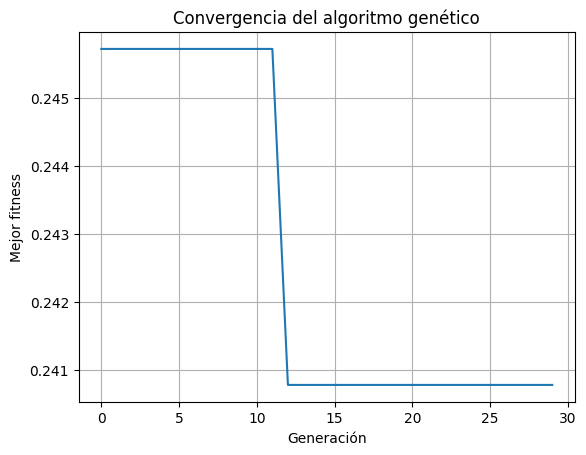

In [185]:
plt.plot(historial_fitness)
plt.xlabel("Generación")
plt.ylabel("Mejor fitness")
plt.title("Convergencia del algoritmo genético")
plt.grid()
plt.show()

In [186]:
tablahistorial.to_excel("historial.xlsx", index=False)